In [61]:
pip install matplotlib seaborn wordcloud

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [62]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [63]:
pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [64]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [65]:
import pandas as pd
import ast
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Load the dataset (adjust the filename if yours is different)
df = pd.read_csv('../data/recipes.csv')

# Look at the first 3 rows
display(df.head(3))

# Check how many rows we have and if there are missing values
print(df.info())

# --- Phase 1: Inspect Dataset (Run this before cleaning!) ---
print("\n1. Dataset Shape (Rows, Columns):")
print(df.shape)

print("\n2. Column Names:")
print(df.columns.tolist())

print("\n3. Data Types:")
print(df.dtypes)

print("\n4. Null (Missing) Values Check:")
print(df.isnull().sum())

,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (..."
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           13501 non-null  int64 
 1   Title                13496 non-null  object
 2   Ingredients          13501 non-null  object
 3   Instructions         13493 non-null  object
 4   Image_Name           13501 non-null  object
 5   Cleaned_Ingredients  13501 non-null  object
dtypes: int64(1), object(5)
memory usage: 633.0+ KB
None

1. Dataset Shape (Rows, Columns):
(13501, 6)

2. Column Names:
['Unnamed: 0', 'Title', 'Ingredients', 'Instructions', 'Image_Name', 'Cleaned_Ingredients']

3. Data Types:
Unnamed: 0              int64
Title                  object
Ingredients            object
Instructions           object
Image_Name             object
Cleaned_Ingredients    object
dtype: object

4. Null (Missing) Values Check:
Unnamed: 0             0
Title              

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import joblib

# A list of words we want to delete from the ingredients
measurements_to_remove = [
    'a', 'an', 'the', 'and', 'or', 'with', 'of', 'in', 'into', 'for', 'to', 'some', 'as', 'at', 'about',
    'of', 'about', 'accompaniment', 'cup', 'cups', 'oz', 'ounce', 'ounces', 'tsp', 'teaspoon', 'teaspoons',
    'tbsp', 'tablespoon', 'tablespoons', 'pound', 'pounds', 'lb', 'lbs',
    'gram', 'grams', 'g', 'kg', 'ml', 'liter', 'liters', 'pint', 'pints',
    'quart', 'quarts', 'gallon', 'gallons', 'pinch', 'dash', 'piece', 'pieces',
    'chopped', 'diced', 'minced', 'sliced', 'peeled', 'fresh', 'large', 'small'
]

def clean_ingredients(ingredient_text):
    try:
        if isinstance(ingredient_text, str) and ingredient_text.startswith('['):
            ingredients_list = ast.literal_eval(ingredient_text)
        else:
            ingredients_list = str(ingredient_text).split(',')
    except:
        return ""

    cleaned_list = []
    for item in ingredients_list:
        item = item.lower()
        item = re.sub(r'[^a-z\s]', '', item)
        words = item.split()
        filtered_words = [word for word in words if word not in measurements_to_remove]
        
        # Combine multi-word ingredients with an underscore (e.g., "rice vinegar" -> "rice_vinegar")
        cleaned_item = "_".join(filtered_words).strip('_')
        
        if cleaned_item:
            cleaned_list.append(cleaned_item)
            
    return " ".join(cleaned_list)

# 3. Process Dataset
print("1/3: Cleaning ingredient text...")
df ['Cleaned_Ingredients'] = df['Ingredients'].apply(clean_ingredients)
df = df.dropna(subset=['Title', 'Ingredients', 'Instructions', 'Cleaned_Ingredients'])
df = df.reset_index(drop=True)

# Save the cleaned data to be used by the website later
df.to_csv('../data/cleaned_recipes.csv', index=False)
print(f"Data cleaned! Remaining valid recipes: {len(df)}")

# 4. Train ML Model (TF-IDF)
print("2/3: Training Machine Learning model...")
vectorizer = TfidfVectorizer(
    max_features=5000,  
    ngram_range=(1, 2), 
    min_df=2,           
    max_df=0.85         
)
tfidf_matrix = vectorizer.fit_transform(df['Cleaned_Ingredients'])

# 5. Train the KNN Machine Learning Model
print("Training KNN Model...")
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(tfidf_matrix)

# 6. Save both models
joblib.dump(vectorizer, '../data/tfidf_vectorizer.pkl')
joblib.dump(knn_model, '../data/knn_model.pkl') 
print("✅ Models trained and saved!")

1/3: Cleaning ingredient text...
Data cleaned! Remaining valid recipes: 13493
2/3: Training Machine Learning model...
Training KNN Model...
✅ Models trained and saved!


In [67]:
# Save the cleaned dataset so we don't have to run the cleaner every time
df.to_csv('../data/cleaned_recipes.csv', index=False)

In [68]:

# 0. Drop any empty rows just in case the cleaning process left blanks
df = df.dropna(subset=['Title', 'Ingredients', 'Instructions', 'Cleaned_Ingredients'])
df = df.reset_index(drop=True)
print(f"Matrix Shape: {tfidf_matrix.shape} (Rows: Recipes, Columns: Unique Ingredients)")

# 2. Build the Recommendation Function
import re

def recommend_recipes_smart_sort(user_ingredients_list, recipe_df, vectorizer_model, knn_model, top_k=5):
    cleaned_user_items = [clean_ingredients(item).strip() for item in user_ingredients_list]
    cleaned_user_items = [item for item in cleaned_user_items if item]
    user_string = " ".join(cleaned_user_items)
    
    # Vectorize the input
    user_vector = vectorizer_model.transform([user_string])
    
    # ASK THE ML MODEL TO FIND THE NEIGHBORS
    # It returns the distances and the row indices of the top 50 matches
    distances, indices = knn_model.kneighbors(user_vector, n_neighbors=50)
    
    # Convert distance to similarity score (1 - distance)
    similarity_scores = 1 - distances.flatten()
    top_50_indices = indices.flatten()
    
    top_results = recipe_df.iloc[top_50_indices].copy()
    top_results['Cosine_Score'] = similarity_scores
    
    
    # The Counter: Count how many inputted ingredients actually appear in the recipe
    def count_matches(recipe_ingredients_string):
        count = 0
        for item in cleaned_user_items:
            # We use \b (word boundary) so it matches the exact token
            if re.search(rf'\b{item}\b', str(recipe_ingredients_string)):
                count += 1
        return count
        
    top_results['Match_Count'] = top_results['Cleaned_Ingredients'].apply(count_matches)
    
    # The Sorter: Sort by Match_Count first (descending), then by Cosine_Score
    final_results = top_results.sort_values(
        by=['Match_Count', 'Cosine_Score'], 
        ascending=[False, False]
    ).head(top_k)
    
    return final_results[['Title', 'Ingredients', 'Cleaned_Ingredients', 'Match_Count', 'Cosine_Score']]

# --- Test the Smart Sorter ---
test_pantry = ['chicken', 'garlic', 'rice vinegar', 'soy sauce']
print(f"Searching for recipes prioritizing ingredient overlap: {test_pantry}\n")
results = recommend_recipes_smart_sort(test_pantry, df, vectorizer, knn_model, top_k=5)
display(results)


Matrix Shape: (13493, 5000) (Rows: Recipes, Columns: Unique Ingredients)
Searching for recipes prioritizing ingredient overlap: ['chicken', 'garlic', 'rice vinegar', 'soy sauce']



,Title,Ingredients,Cleaned_Ingredients,Match_Count,Cosine_Score
119,Pajeon Sauce,"['2 tablespoons water', '2 tablespoons rice vi...",water rice_vinegar soy_sauce gochugaru_korean_...,2,0.575700
5525,"Three Peas with Barley, Chile & Green Garlic","['kosher salt', 'sugar snap peas, 6 oz (185 g)...",kosher_salt sugar_snap_peas_trimmed english_pe...,2,0.472604
12570,Spicy Asian Marinade,"['3 tablespoons soy sauce', '2 tablespoons ric...",soy_sauce rice_wine_sake garlic dried_chile_fl...,2,0.466473
735,Cashew Chicken,"['2 Tbsp. oyster sauce', '1 Tbsp. rice vinegar...",oyster_sauce rice_vinegar soy_sauce light_brow...,2,0.466111
1134,Cold Sesame Noodles with Cucumber,"['8 ounces Chinese egg noodles, cappellini, or...",chinese_egg_noodles_cappellini_pad_thai_style_...,2,0.382657


/var/folders/00/45cm1jfj0nq_87yby0dthxb40000gn/T/ipykernel_14119/666991495.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


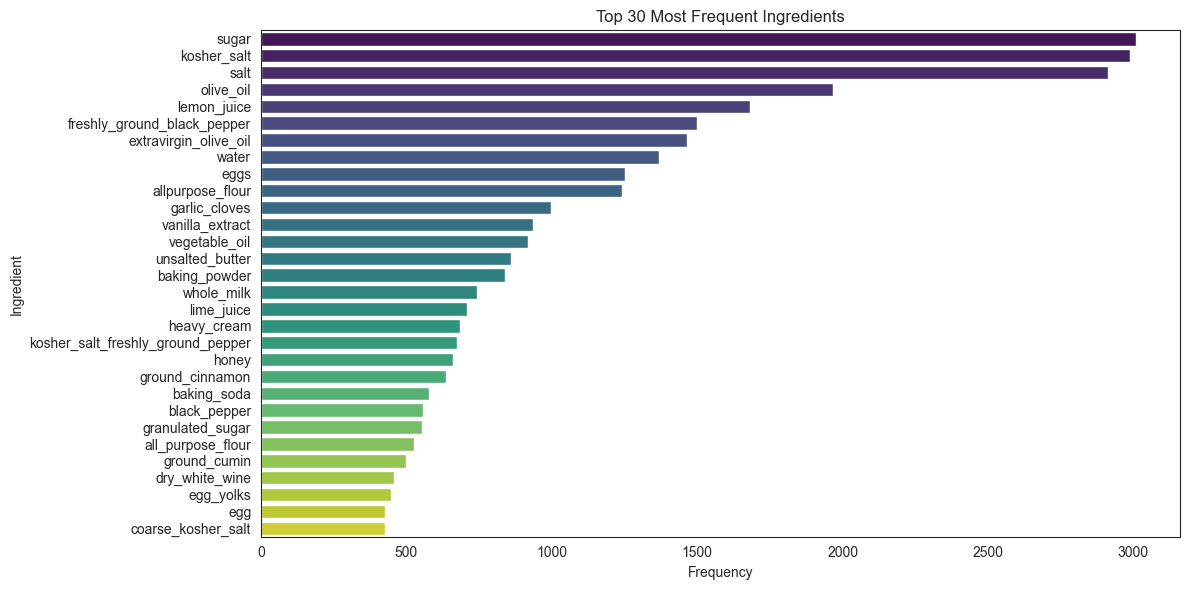

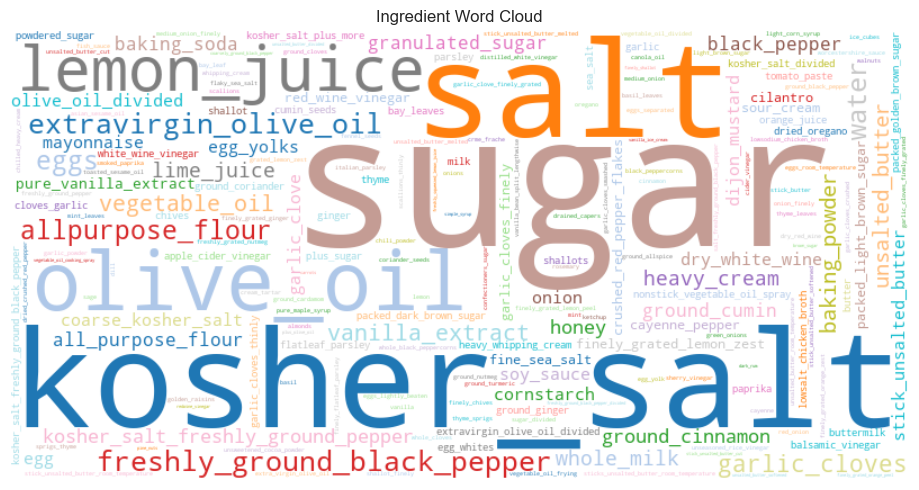

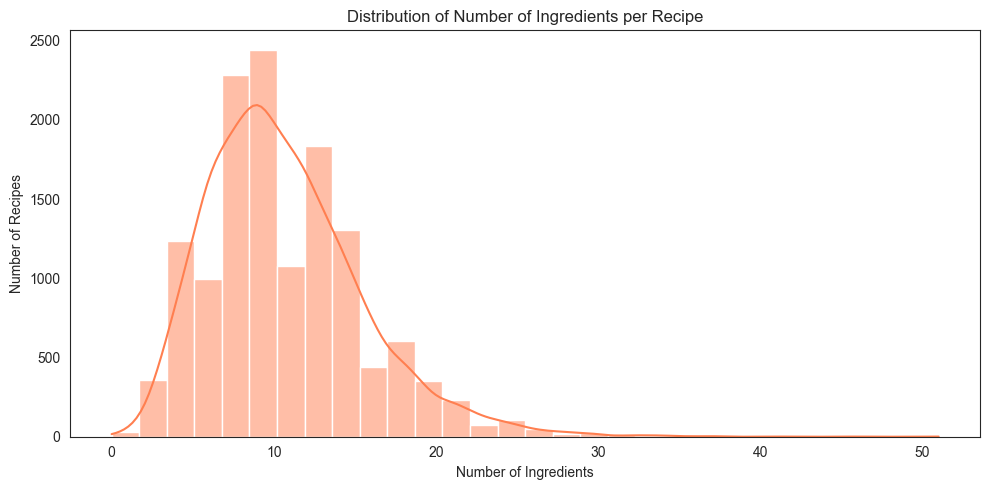

/var/folders/00/45cm1jfj0nq_87yby0dthxb40000gn/T/ipykernel_14119/666991495.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette="mako")


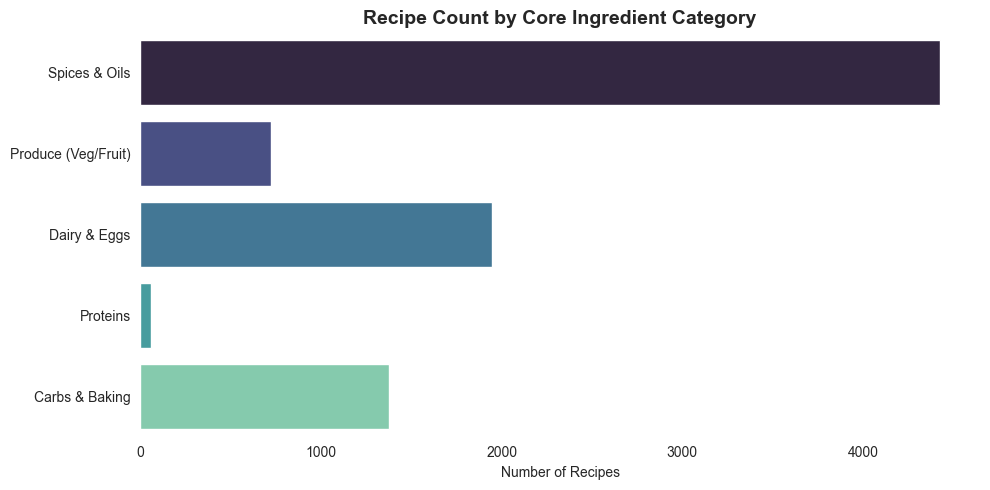

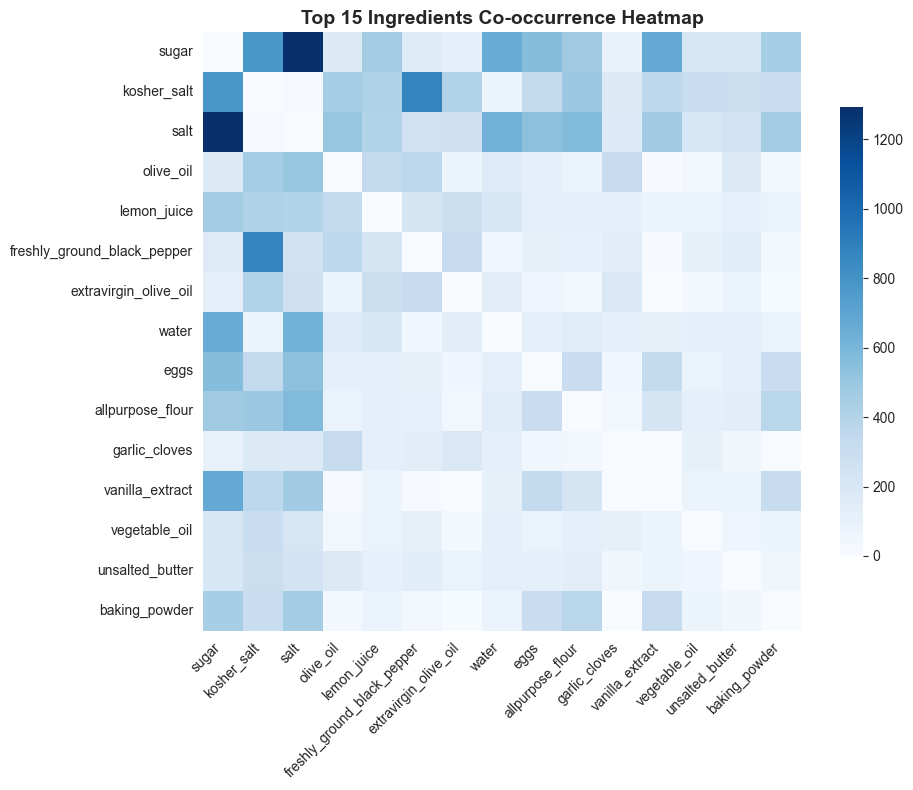

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# 1. Ingredient Frequency Distribution (Top 30) [cite: 25]
all_words = " ".join(df['Cleaned_Ingredients'].astype(str).tolist()).split()
word_counts = Counter(all_words)
top_30_ingredients = word_counts.most_common(30)

words, counts = zip(*top_30_ingredients)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title('Top 30 Most Frequent Ingredients')
plt.xlabel('Frequency')
plt.ylabel('Ingredient')
plt.tight_layout()
plt.savefig('top_30_ingredients.png') # Saves for your PPT!
plt.show()

# 2. Word Cloud [cite: 26]
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20').generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Ingredient Word Cloud')
plt.tight_layout()
plt.savefig('ingredient_wordcloud.png') # Saves for your PPT!
plt.show()

# 3. Average Number of Ingredients per Recipe (Histogram)
# Count how many ingredients are in each recipe
df['Ingredient_Count'] = df['Cleaned_Ingredients'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['Ingredient_Count'], bins=30, kde=True, color='coral')
plt.title('Distribution of Number of Ingredients per Recipe')
plt.xlabel('Number of Ingredients')
plt.ylabel('Number of Recipes')
plt.tight_layout()
plt.savefig('ingredient_count_histogram.png') # Saves for your PPT!
plt.show()

# 4. Recipe Count per Ingredient Category (Fulfills Checklist Requirement)
import numpy as np

# Define simple categories for common ingredients
categories = {
    'Spices & Oils': ['salt', 'pepper', 'oil', 'sugar', 'vanilla', 'cinnamon', 'vinegar', 'soy'],
    'Produce (Veg/Fruit)': ['garlic', 'onion', 'lemon', 'tomato', 'potato', 'carrot', 'apple', 'spinach'],
    'Dairy & Eggs': ['butter', 'cheese', 'egg', 'eggs', 'milk', 'cream', 'parmesan'],
    'Proteins': ['chicken', 'beef', 'pork', 'bacon', 'sausage', 'fish', 'shrimp'],
    'Carbs & Baking': ['flour', 'water', 'rice', 'pasta', 'bread', 'yeast', 'oats']
}

category_counts = {cat: 0 for cat in categories.keys()}

# Count recipes containing at least one ingredient from each category
for index, row in df.iterrows():
    recipe_ingredients = str(row['Cleaned_Ingredients']).split()
    for cat, items in categories.items():
        if any(item in recipe_ingredients for item in items):
            category_counts[cat] += 1

# Minimalist Bar Chart
plt.figure(figsize=(10, 5))
sns.set_style("white") # Clean, classy background
ax = sns.barplot(x=list(category_counts.values()), y=list(category_counts.keys()), palette="mako")

plt.title('Recipe Count by Core Ingredient Category', fontsize=14, fontweight='bold')
plt.xlabel('Number of Recipes')
plt.ylabel('')
sns.despine(left=True, bottom=True) # Removes border lines for a cleaner look

plt.tight_layout()
plt.savefig('ingredient_categories.png')
plt.show()

# 5. Ingredient Co-occurrence Heatmap (Advanced EDA for ML Justification)
from sklearn.feature_extraction.text import CountVectorizer

# Get the top 15 most common ingredients to avoid a messy, massive chart
top_15_words = [word for word, count in word_counts.most_common(15)]

# Create a matrix of just those 15 words
cv = CountVectorizer(vocabulary=top_15_words)
word_matrix = cv.fit_transform(df['Cleaned_Ingredients'].astype(str))

# Multiply the matrix by its transpose to get co-occurrences
co_occurrence_matrix = (word_matrix.T * word_matrix).toarray()
np.fill_diagonal(co_occurrence_matrix, 0) # Remove self-matching (e.g., Salt matching with Salt)

# Elegant Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, xticklabels=top_15_words, yticklabels=top_15_words, 
            cmap="Blues", annot=False, square=True, cbar_kws={"shrink": .75})

plt.title('Top 15 Ingredients Co-occurrence Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ingredient_heatmap.png')
plt.show()

In [70]:
import time

# --- Phase 2: Build Jaccard Similarity Baseline 
def jaccard_similarity(user_list, recipe_string):
    user_set = set(user_list)
    recipe_set = set(str(recipe_string).split())
    
    intersection = len(user_set.intersection(recipe_set))
    union = len(user_set.union(recipe_set))
    
    if union == 0:
        return 0
    return intersection / union # Jaccard formula 

def recommend_jaccard(user_ingredients, recipe_df, top_k=5):
    # We assume user_ingredients is already a cleaned list of words
    scores = recipe_df['Cleaned_Ingredients'].apply(lambda x: jaccard_similarity(user_ingredients, x))
    
    top_results = recipe_df.copy()
    top_results['Jaccard_Score'] = scores
    return top_results.sort_values(by='Jaccard_Score', ascending=False).head(top_k)

# --- Phase 4: Model Evaluation (Speed Test) 
test_input = ['chicken', 'garlic', 'onion', 'soy_sauce']
print(f"Testing Models with ingredients: {test_input}\n")

# 1. Time the Jaccard Model
start_time = time.time()
jaccard_results = recommend_jaccard(test_input, df)
jaccard_time = time.time() - start_time

print(f"⏱️ Jaccard Baseline Execution Time: {jaccard_time:.4f} seconds")
display(jaccard_results[['Title', 'Jaccard_Score']])

# 2. Time the Official KNN Machine Learning Model
start_time = time.time()
user_search_string = " ".join(test_input)
user_vector = vectorizer.transform([user_search_string])

# Use KNN instead of manual cosine
distances, indices = knn_model.kneighbors(user_vector, n_neighbors=5)
sim_scores = 1 - distances.flatten()
top_indices = indices.flatten()

knn_time = time.time() - start_time

print(f"\n⏱️ TF-IDF + KNN Execution Time: {knn_time:.4f} seconds")
knn_results = df.iloc[top_indices].copy()
knn_results['Cosine_Score'] = sim_scores
display(knn_results[['Title', 'Cosine_Score']])

Testing Models with ingredients: ['chicken', 'garlic', 'onion', 'soy_sauce']

⏱️ Jaccard Baseline Execution Time: 0.0726 seconds


,Title,Jaccard_Score
12570,Spicy Asian Marinade,0.285714
4399,Filipino-Style Chicken Adobo,0.250000
10408,Chinese Barbecued Baby Back Ribs,0.222222
2372,Stir-Fried Chicken With Black Beans,0.214286
9020,Warm Tofu with Spicy Garlic Sauce,0.200000



⏱️ TF-IDF + KNN Execution Time: 0.0040 seconds


,Title,Cosine_Score
5439,Beer-Can Chicken,0.655908
12570,Spicy Asian Marinade,0.632088
2907,Slow-Roasted Chicken With All the Garlic,0.498228
11249,"Chicken with Bell Peppers, Smoked Ham, and Pap...",0.437634
1472,Feel-Good Chicken Soup,0.413087


In [72]:
# --- Phase 4: Precision@K Evaluation ---
# 1. Define 10 diverse test cases (Fulfills: "Define ground-truth test cases")
test_cases = [
    ['chicken', 'garlic', 'onion'],
    ['beef', 'broccoli', 'soy_sauce'],
    ['pasta', 'tomato', 'basil', 'cheese'],
    ['egg', 'bacon', 'bread'],
    ['salmon', 'lemon', 'butter'],
    ['potato', 'cheese', 'milk'],
    ['flour', 'sugar', 'egg', 'butter', 'vanilla'],
    ['shrimp', 'garlic', 'oil', 'parsley'],
    ['pork', 'apple', 'onion'],
    ['rice', 'chicken', 'carrot', 'pea']
]

def calculate_precision(recommended_df, input_ingredients, k):
    relevant_count = 0
    top_k_recipes = recommended_df.head(k)
    
    # Require 2 matches if they asked for multiple ingredients
    required_matches = 2 if len(input_ingredients) > 1 else 1
    
    for _, row in top_k_recipes.iterrows():
        # Treat the ingredients as one giant string of text
        recipe_string = str(row['Cleaned_Ingredients'])
        
        # Check if the word is ANYWHERE inside that string (ignoring underscores!)
        match_count = sum(1 for item in input_ingredients if item in recipe_string)
        
        if match_count >= required_matches:
            relevant_count += 1
            
    return relevant_count / k

# 2. Run the tests and collect scores
print("Running 10 Test Cases for Precision@K...\n")

jaccard_p3, jaccard_p5 = [], []
knn_p3, knn_p5 = [], [] # Renamed to reflect our ML upgrade!

for i, test in enumerate(test_cases):
    # Evaluasi Jaccard Baseline
    j_results = recommend_jaccard(test, df, top_k=5)
    jaccard_p3.append(calculate_precision(j_results, test, 3))
    jaccard_p5.append(calculate_precision(j_results, test, 5))
    
    # Evaluasi Official KNN Machine Learning Model
    k_results = recommend_recipes_smart_sort(test, df, vectorizer, knn_model, top_k=5)
    knn_p3.append(calculate_precision(k_results, test, 3))
    knn_p5.append(calculate_precision(k_results, test, 5))

# 3. Print the Final Report for your PPT!
print("-" * 40)
print("📊 FINAL MODEL EVALUATION (Averages)")
print("-" * 40)
print(f"Jaccard Baseline -> Precision@3: {sum(jaccard_p3)/10:.2%} | Precision@5: {sum(jaccard_p5)/10:.2%}")
print(f"KNN Main Model   -> Precision@3: {sum(knn_p3)/10:.2%} | Precision@5: {sum(knn_p5)/10:.2%}")

Running 10 Test Cases for Precision@K...

----------------------------------------
📊 FINAL MODEL EVALUATION (Averages)
----------------------------------------
Jaccard Baseline -> Precision@3: 30.00% | Precision@5: 34.00%
KNN Main Model   -> Precision@3: 56.67% | Precision@5: 50.00%


📊 Model Comparison Table:


,Model,Metric,Score (%)
0,Jaccard Baseline,Precision@3,30.00
1,Jaccard Baseline,Precision@5,34.00
2,TF-IDF + KNN,Precision@3,56.67
3,TF-IDF + KNN,Precision@5,50.00


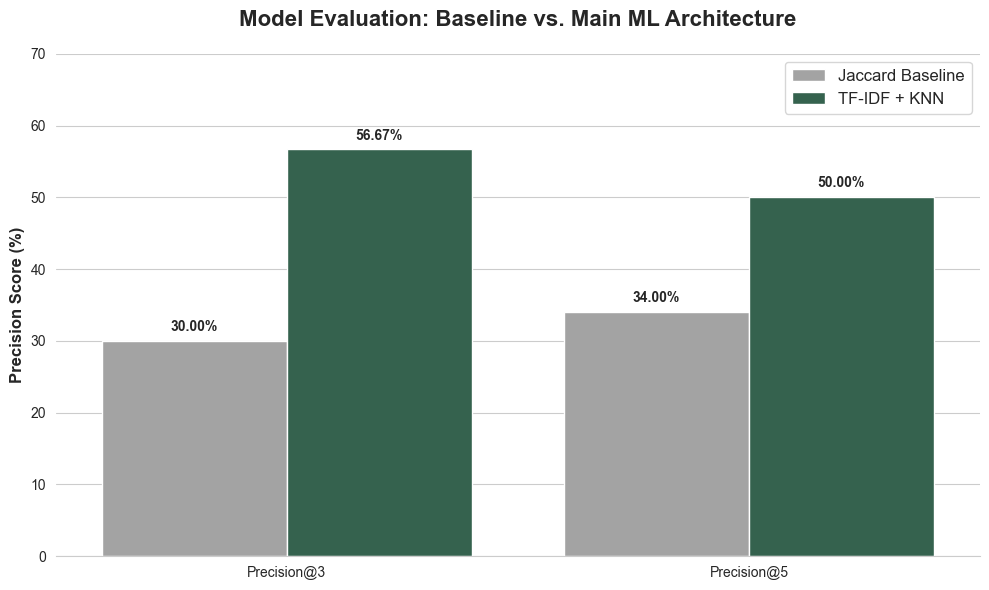

✅ Chart saved perfectly your project folder.


In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the Comparison Table Data
data = {
    'Model': ['Jaccard Baseline', 'Jaccard Baseline', 'TF-IDF + KNN', 'TF-IDF + KNN'],
    'Metric': ['Precision@3', 'Precision@5', 'Precision@3', 'Precision@5'],
    'Score (%)': [30.00, 34.00, 56.67, 50.00]
}
comp_df = pd.DataFrame(data)

print("📊 Model Comparison Table:")
display(comp_df)

# 2. Create the Presentation-Ready Chart
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") # Clean background for presentations

# Create a grouped bar chart with custom colors
ax = sns.barplot(
    x='Metric', 
    y='Score (%)', 
    hue='Model', 
    data=comp_df, 
    palette=['#a3a3a3', '#2d6a4f'] # Gray for baseline, bold green for your winning model
)

# Add titles and formatting
plt.title('Model Evaluation: Baseline vs. Main ML Architecture', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 70) # Set Y-axis slightly higher than max score for headroom
plt.ylabel('Precision Score (%)', fontsize=12, fontweight='bold')
plt.xlabel('')

# Add the exact percentages on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5, fontweight='bold')
    
plt.legend(title='', fontsize=12, loc='upper right')
sns.despine(left=True) # Remove borders for a modern look

# Save and show
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300) # High-res save for your PPT!
plt.show()

print("✅ Chart saved perfectly your project folder.")